In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Loading all datasets**

In [3]:
claims = pd.read_csv("claims_data.csv")
food = pd.read_csv("food_listings_data.csv")
providers = pd.read_csv("providers_data.csv")
receivers = pd.read_csv("receivers_data.csv")

**shapes of files**

In [16]:
claims.info()
food.info()
providers.info()
receivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Claim_ID     1000 non-null   int64 
 1   Food_ID      1000 non-null   int64 
 2   Receiver_ID  1000 non-null   int64 
 3   Status       1000 non-null   object
 4   Timestamp    1000 non-null   object
dtypes: int64(3), object(2)
memory usage: 39.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Food_ID        1000 non-null   int64 
 1   Food_Name      1000 non-null   object
 2   Quantity       1000 non-null   int64 
 3   Expiry_Date    1000 non-null   object
 4   Provider_ID    1000 non-null   int64 
 5   Provider_Type  1000 non-null   object
 6   Location       1000 non-null   object
 7   Food_Type      1000 non-null   object
 8   Meal_Type      10

**Checking nulls & Duplicates**

In [36]:
print("Providers Missing Values")
print(providers.isnull().sum())
print("Receivers Missing Values")
print(receivers.isnull().sum())
print("Claims Missing Values")
print(claims.isnull().sum())
print("Food Missing Values")
print(food.isnull().sum())

Providers Missing Values
Provider_ID    0
Name           0
Type           0
Address        0
City           0
Contact        0
dtype: int64
Receivers Missing Values
Receiver_ID    0
Name           0
Type           0
City           0
Contact        0
dtype: int64
Claims Missing Values
Claim_ID       0
Food_ID        0
Receiver_ID    0
Status         0
Timestamp      0
dtype: int64
Food Missing Values
Food_ID          0
Food_Name        0
Quantity         0
Expiry_Date      0
Provider_ID      0
Provider_Type    0
Location         0
Food_Type        0
Meal_Type        0
dtype: int64


In [37]:
print("Providers Duplicates")
print(providers.duplicated().sum())
print("Receivers Duplicates")
print(receivers.duplicated().sum())
print("Claims Duplicates")
print(claims.duplicated().sum())
print("Food Duplicates")
print(food.duplicated().sum())

Providers Duplicates
0
Receivers Duplicates
0
Claims Duplicates
0
Food Duplicates
0


In [38]:
print(providers.isnull().sum()[providers.isnull().sum() > 0])
print(receivers.isnull().sum()[receivers.isnull().sum() > 0])
print(food.isnull().sum()[food.isnull().sum() > 0])
print(claims.isnull().sum()[claims.isnull().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


**Strandadize Columns**

In [56]:
receivers.columns = (receivers.columns.str.lower().str.strip())
providers.columns = (providers.columns.str.lower().str.strip())
claims.columns = (claims.columns.str.lower().str.strip())
food.columns = (food.columns.str.lower().str.strip())

# **Univariate Analysis**

***Provider Type Distribution***

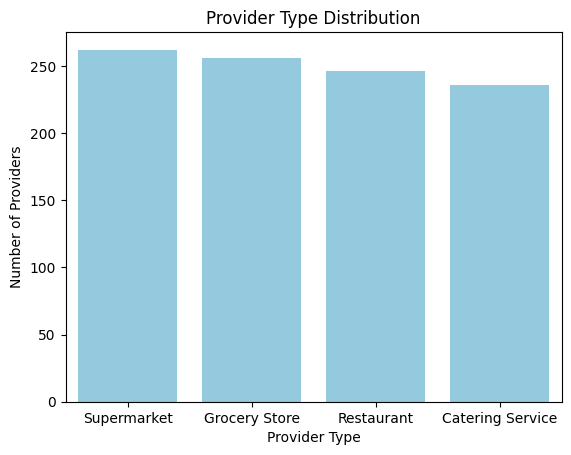

In [100]:
sns.countplot(data=providers,x='type',color='skyblue')
plt.xlabel('Provider Type')
plt.ylabel('Number of Providers')
plt.title('Provider Type Distribution')
plt.show()


***Receiver Type Distribution***

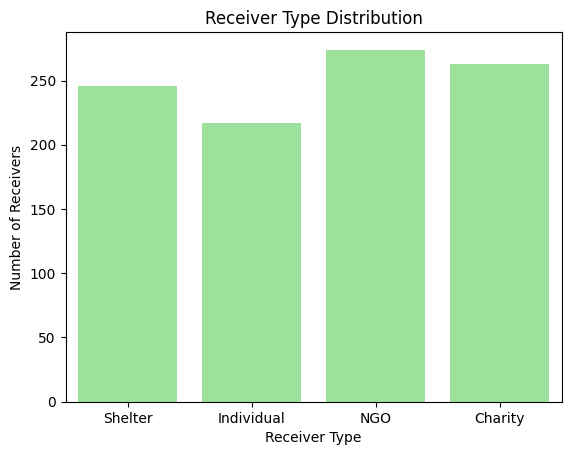

In [101]:
sns.countplot(data=receivers,x='type',color='lightgreen')
plt.xlabel('Receiver Type')
plt.ylabel('Number of Receivers')
plt.title('Receiver Type Distribution')
plt.show()

***Food Type Distribution***

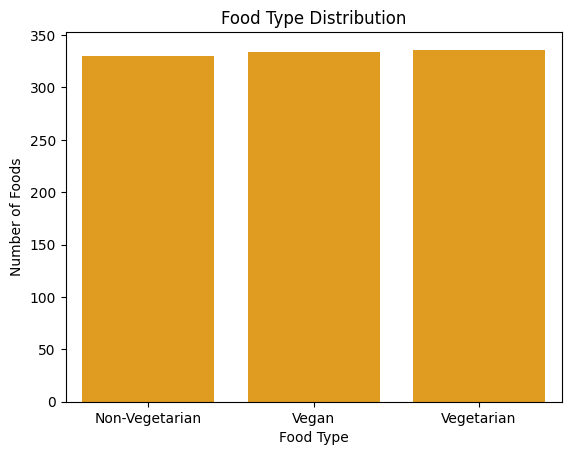

In [102]:
sns.countplot(data=food,x='food_type',color='orange')
plt.xlabel('Food Type')
plt.ylabel('Number of Foods')
plt.title('Food Type Distribution')
plt.show()

***Meal Type Distribution***

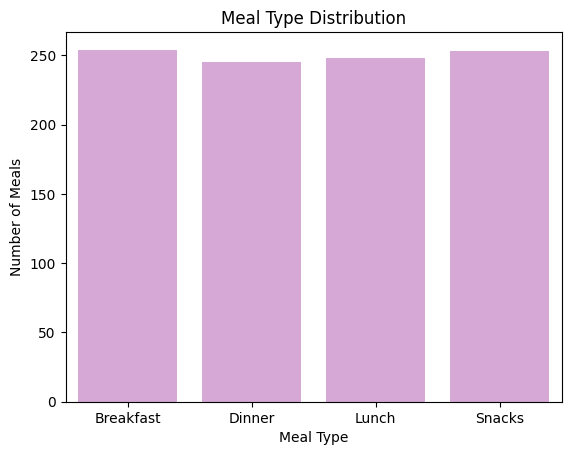

In [103]:
sns.countplot(data=food,x='meal_type',color='plum')
plt.xlabel('Meal Type')
plt.ylabel('Number of Meals')
plt.title('Meal Type Distribution')
plt.show()

# **Bivariate Analysis**

**location vs food listings**

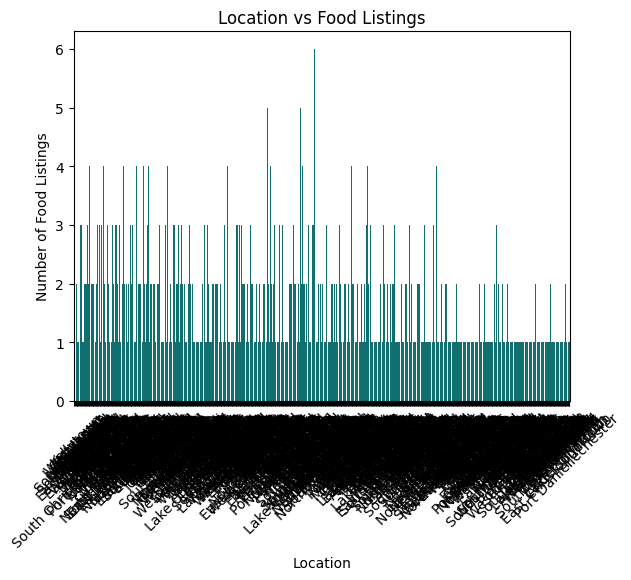

In [104]:
sns.countplot(data=food,x='location',color='teal')
plt.xlabel('Location')
plt.ylabel('Number of Food Listings')
plt.title('Location vs Food Listings')
plt.xticks(rotation=45)
plt.show()

***Provider type vs Quantity***

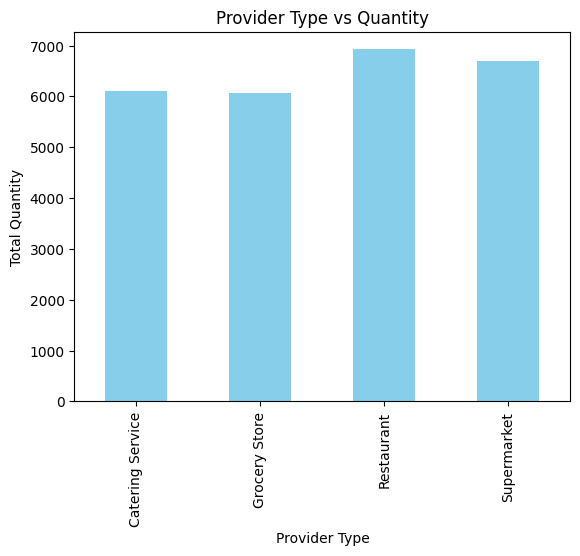

In [105]:
food.groupby('provider_type')['quantity'].sum().plot(kind='bar',color='skyblue')
plt.xlabel('Provider Type')
plt.ylabel('Total Quantity')
plt.title('Provider Type vs Quantity')
plt.show()

***Food Type vs Quantity***

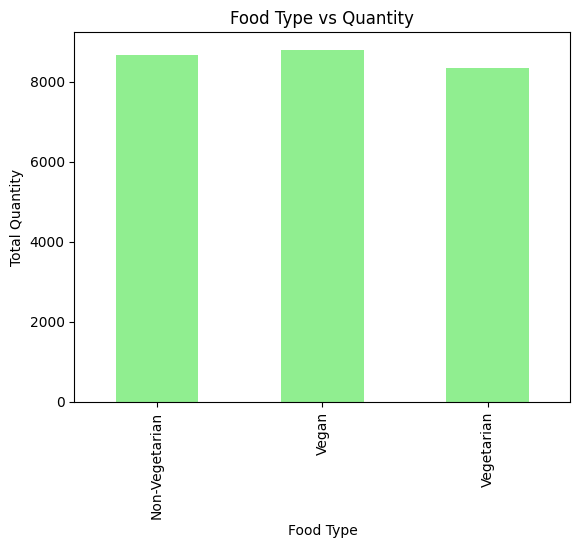

In [106]:
food.groupby('food_type')['quantity'].sum().plot(kind='bar',color='lightgreen')
plt.xlabel('Food Type')
plt.ylabel('Total Quantity')
plt.title('Food Type vs Quantity')
plt.show()

***Meal Type vs quantity***

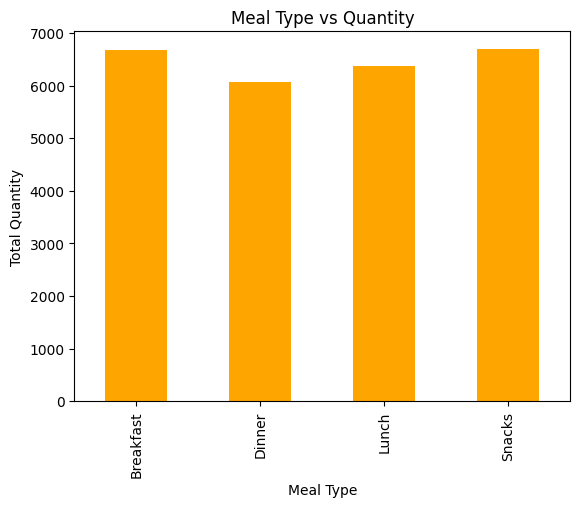

In [108]:
food.groupby('meal_type')['quantity'].sum().plot(kind='bar',color='orange')
plt.xlabel('Meal Type')
plt.ylabel('Total Quantity')
plt.title('Meal Type vs Quantity')
plt.show()

# **Multivariate Analysis**

***city+providertype+quantity***

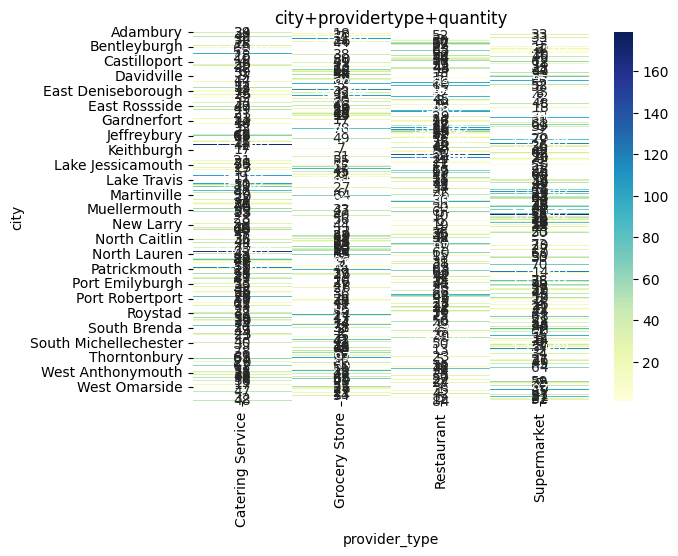

In [107]:
food_provider = pd.merge(food,providers,on='provider_id')
p1=food_provider.pivot_table(index='city',columns='provider_type',values='quantity',aggfunc='sum')
sns.heatmap(p1,annot=True,cmap='YlGnBu')
plt.title('city+providertype+quantity')
plt.show()

***Food_type+Meal_type+quantity***

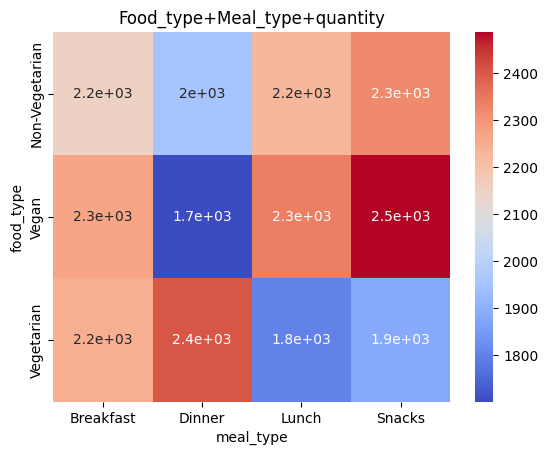

In [115]:
p2=food.pivot_table(index='food_type',columns='meal_type',values='quantity',aggfunc='sum')
sns.heatmap(p2,annot=True,cmap='coolwarm')
plt.title('Food_type+Meal_type+quantity')
plt.show()

**Insights:**
2.2e+03 means 2200 units of food
similarly 1.7e+03 1700 units of food

***Providers+claims+quantity***

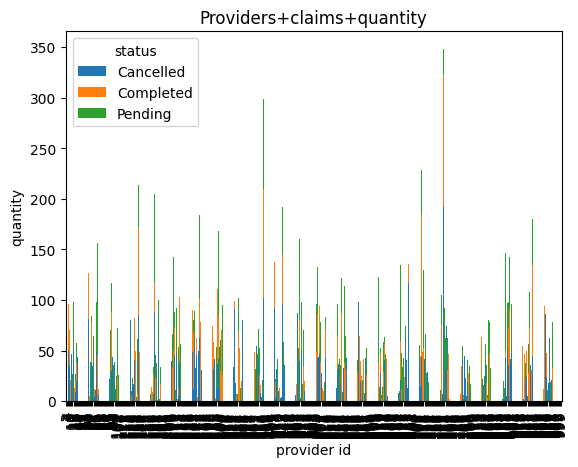

In [110]:
a = pd.merge(food,claims,on='food_id')
p3=a.pivot_table(values='quantity',index='provider_id',columns='status',aggfunc='sum')
p3.plot(kind='bar',stacked=True)
plt.xlabel('provider id')
plt.ylabel('quantity')
plt.title('Providers+claims+quantity')
plt.show()

***Receiver+Claims+Quantity***

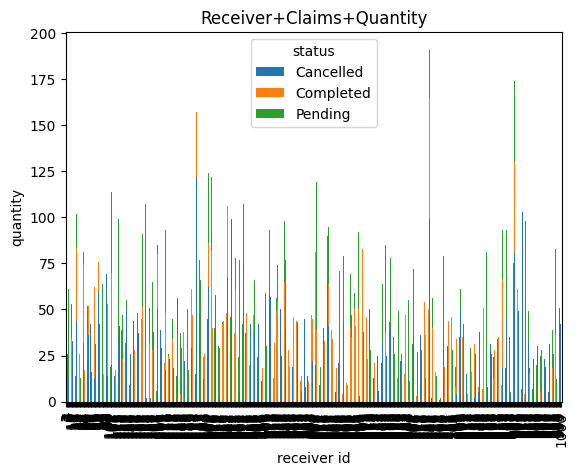

In [111]:
p4 = a.pivot_table(values='quantity',index='receiver_id',columns='status',aggfunc='sum')
p4.plot(kind='bar',stacked=True)
plt.xlabel('receiver id')
plt.ylabel('quantity')
plt.title('Receiver+Claims+Quantity')
plt.show()

# **Claim Analysis**

***Claim Status Distribution***

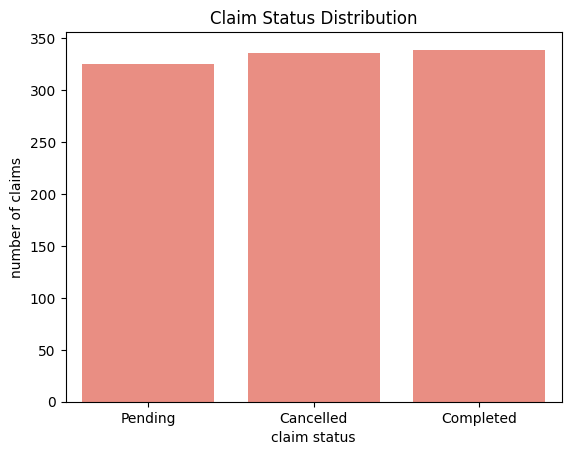

In [112]:
sns.countplot(data=claims,x='status',color='salmon')
plt.xlabel('claim status')
plt.ylabel('number of claims')
plt.title('Claim Status Distribution')
plt.show()

***Top Recievers***

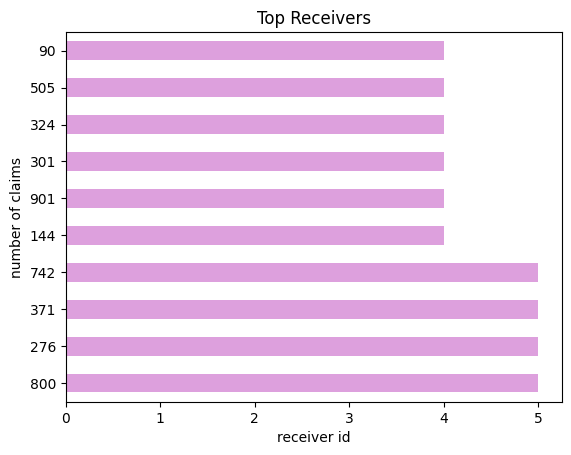

In [113]:
claims['receiver_id'].value_counts().head(10).plot(kind='barh',color='plum')
plt.xlabel('receiver id')
plt.ylabel('number of claims')
plt.title('Top Receivers')
plt.show()

***Top Providers***

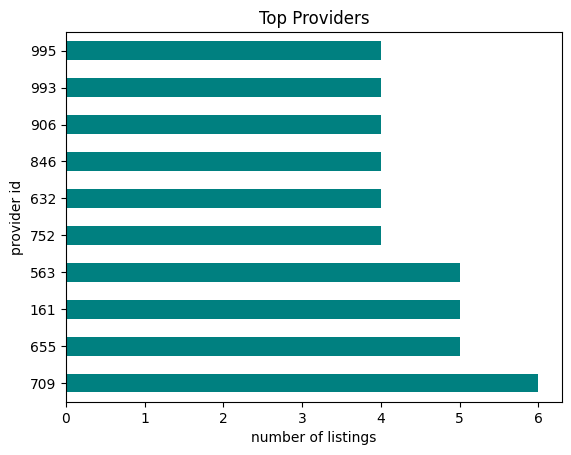

In [114]:
food['provider_id'].value_counts().head(10).plot(kind='barh',color='teal')
plt.xlabel('number of listings')
plt.ylabel('provider id')
plt.title('Top Providers')
plt.show()

In [122]:
food.columns

Index(['food_id', 'food_name', 'quantity', 'expiry_date', 'provider_id',
       'provider_type', 'location', 'food_type', 'meal_type'],
      dtype='object')

In [123]:
food['expiry_date'] = pd.to_datetime(food['expiry_date']).dt.strftime('%Y-%m-%d')

In [124]:
print(food['expiry_date'].head())

0    2025-03-17
1    2025-03-24
2    2025-03-28
3    2025-03-16
4    2025-03-19
Name: expiry_date, dtype: object


**Saving Files**

In [121]:
claims.to_csv('claims_cleaned.csv',index=False,sep=',')
providers.to_csv('providers_cleaned.csv',index=False,sep=',')
receivers.to_csv('receivers_cleaned.csv',index=False,sep=',')

In [125]:
food.to_csv('food_listings_cleaned.csv',index=False,sep=',')